/var/folders/x3/z35rtwhs2j7gt3thbjwqvcx80000gn/T/ipykernel_72594/2038950805.py:78: DtypeWarning: Columns (6,7,11,12,16,17,21,22,26,27,31,32,36,37,41,42,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../output/01_merged_data.csv')


Analyzing 45234 total records.


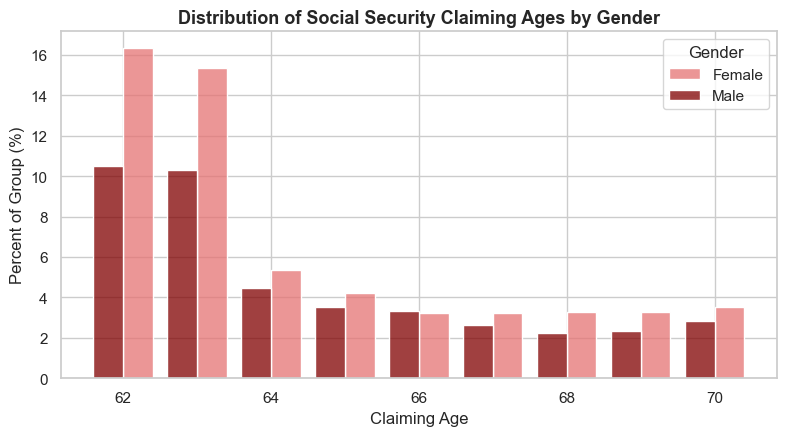

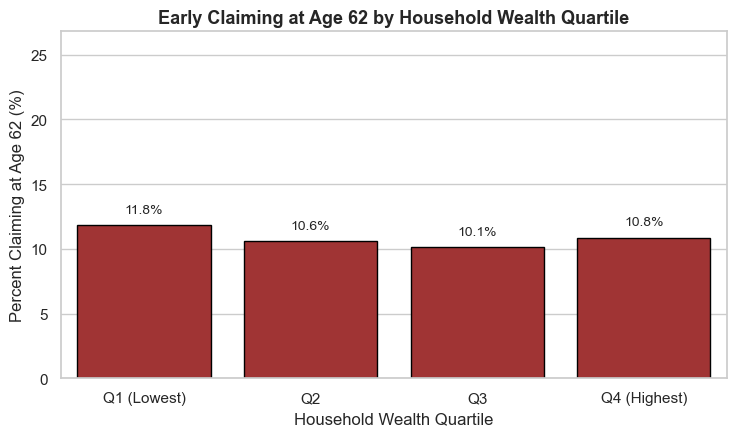

N used in figures: 18,241
Regression sample size: 18241
--- OLS: claim_age ~ female + avg_wealth ---
                            OLS Regression Results                            
Dep. Variable:              claim_age   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     20.46
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           1.33e-09
Time:                        12:36:43   Log-Likelihood:                -43022.
No. Observations:               18241   AIC:                         8.605e+04
Df Residuals:                   18238   BIC:                         8.607e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

def run_visualizations(df):
    sns.set_theme(style='whitegrid')
    plt.rcParams.update({'font.size': 11})
# Generates and saves the claiming age distribution and wealth impact charts.

    # Figure 1: claiming age distribution by gender.
    # Drop NAs so the histplot doesn't skew or break
    fig_data = df.dropna(subset=['claim_age', 'female'])
    plt.figure(figsize=(8, 4.5))
    sns.histplot(
        data=fig_data, x='claim_age', hue='female', discrete=True,
        multiple='dodge', stat='percent', shrink=0.8,
        palette=['#800000', '#E57373']
    )
    plt.title('Distribution of Social Security Claiming Ages by Gender', fontsize=13, fontweight='bold')
    plt.xlabel('Claiming Age')
    plt.ylabel('Percent of Group (%)')
    plt.legend(title='Gender', labels=['Female', 'Male'])
    plt.tight_layout()
    plt.savefig('../output/fig1_claiming_age.png', dpi=300)
    plt.show()

    # Figure 2: share claiming exactly at 62, by wealth quartile.
    wealth_summary = df.groupby('wealth_quartile', observed=False)['claimed_at_62'].mean().reset_index()
    wealth_summary['percent_62'] = wealth_summary['claimed_at_62'].fillna(0) * 100

    plt.figure(figsize=(7.5, 4.5))
    ax2 = sns.barplot(
        data=wealth_summary, x='wealth_quartile', y='percent_62',
        color='#B22222', edgecolor='black'
    )
    plt.title('Early Claiming at Age 62 by Household Wealth Quartile', fontsize=13, fontweight='bold')
    plt.xlabel('Household Wealth Quartile')
    plt.ylabel('Percent Claiming at Age 62 (%)')
    
# Dynamically scale the y-axis so the labels don't get cut off
    max_val = wealth_summary['percent_62'].max()
    plt.ylim(0, 60 if pd.isna(max_val) or max_val == 0 else max_val + 15)
# Annotate the exact percentages on top of the bars
    for p in ax2.patches:
        h = p.get_height()
        if pd.notna(h) and h > 0:
            ax2.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2, h + 1), ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig('../output/fig2_wealth_quartiles.png', dpi=300)
    plt.show()

    return fig_data


def run_regressions(df):
# Fit OLS and logistic models relating gender and wealth to claiming behavior
# Complete-case sample for the regression variables.
    reg_data = df.dropna(subset=['claimed_at_62', 'claim_age', 'female', 'avg_wealth']).copy()
    print(f"Regression sample size: {len(reg_data)}")

    # Continuous outcome: does gender or wealth shift the claiming age itself?
    print("--- OLS: claim_age ~ female + avg_wealth ---")
    ols_model = smf.ols('claim_age ~ female + avg_wealth', data=reg_data).fit()
    print(ols_model.summary())

    print("\n" + "=" * 80 + "\n")

    # Binary outcome: probability of claiming at exactly age 62.
    print("--- Logit: claimed_at_62 ~ female + avg_wealth ---")
    logit_model = smf.logit('claimed_at_62 ~ female + avg_wealth', data=reg_data).fit(disp=0)
    print(logit_model.summary())

    return ols_model, logit_model


df = pd.read_csv('../output/01_merged_data.csv')
print(f"Analyzing {len(df)} total records.")

fig_data = run_visualizations(df)
print(f"N used in figures: {len(fig_data):,}")

ols_model, logit_model = run_regressions(df)

# Quick sign check on the wealth coefficients before writing up results.
print("\nWealth coefficient (OLS):", round(ols_model.params['avg_wealth'], 6))
print("Wealth coefficient (logit):", round(logit_model.params['avg_wealth'], 6))

print("Analysis complete.")